In [1]:
import os
import numpy as np
import torch  # For GPU detection
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
import time
import seaborn as sns

In [2]:
warnings.filterwarnings("ignore")

<h1>Loading the data classes</h1>

In [3]:
# Check GPU availability using PyTorch
print("PyTorch GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("\nTensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)

PyTorch GPU Available: True
GPU Device: NVIDIA GeForce RTX 5070 Ti
GPU Memory: 17.09 GB

TensorFlow version: 2.21.0
PyTorch version: 2.11.0+cu126


In [4]:
# TensorFlow automatically uses GPU if available
print("Mixed precision enabled:", tf.keras.mixed_precision.global_policy().name)

Mixed precision enabled: float32


In [5]:
cloudy_dir = "./data/cloudy"
desert_dir = "./data/desert"
green_area_dir = "./data/green_area"
vehicles_dir = "./data/vehicles"
water_dir = "./data/water"

In [6]:
cloudy = os.listdir(cloudy_dir)[:5]
desert = os.listdir(desert_dir)[:5]
green_area = os.listdir(green_area_dir)[:5]
vehicles = os.listdir(vehicles_dir)[:5]
water = os.listdir(water_dir)[:5]

In [7]:
cloudy_img = Image.open(os.path.join(cloudy_dir, cloudy[0]))
desert_img = Image.open(os.path.join(desert_dir, desert[0]))
green_area_img = Image.open(os.path.join(green_area_dir, green_area[0]))
vehicles_img = Image.open(os.path.join(vehicles_dir, vehicles[0]))
water_img = Image.open(os.path.join(water_dir, water[0]))

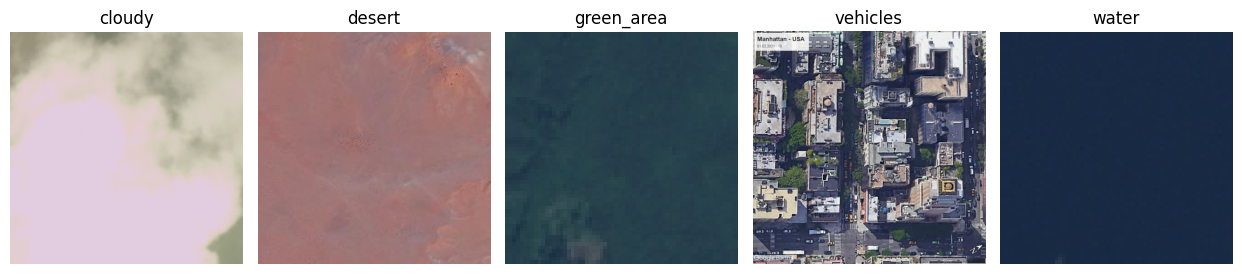

In [8]:
images = [cloudy_img, desert_img, green_area_img, vehicles_img, water_img]
titles = ["cloudy", "desert", "green_area", "vehicles", "water"]

plt.figure(figsize=(15,5))

for i in range(len(images)):
    plt.subplot(1, 6, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

<h1>Data Understanding, Analysis, Visualization and Cleaning</h1>

In [9]:
"""
Converting the images into arrays
"""
cloudy_array = np.array(cloudy_img)
desert_array = np.array(desert_img)
green_area_array = np.array(green_area_img)
vehicles_array = np.array(vehicles_img)
water_array = np.array(water_img)

In [10]:
# Define image size and normalization for ImageNet pre-trained models
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ImageNet normalization values (used by VGG16)
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

def load_and_preprocess_image(path, label, is_training=False):
    """Load image and apply preprocessing for ImageNet pre-trained models"""
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, IMG_SIZE)
    
    # Normalize using ImageNet statistics
    image = (image - MEAN) / STD
    
    return image, label

def create_dataset(image_paths, labels, is_training=False):
    """Create tf.data.Dataset from image paths and labels"""
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if is_training:
        ds = ds.shuffle(buffer_size=len(image_paths))
        ds = ds.map(lambda x, y: load_and_preprocess_image(x, y, is_training=True),
                   num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.prefetch(tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: load_and_preprocess_image(x, y, is_training=False),
                   num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.prefetch(tf.data.AUTOTUNE)
    
    return ds

In [11]:
# Collect all image paths and labels
def collect_dataset(cloudy_dir, desert_dir, green_area_dir, vehicles_dir, water_dir):
    """Collect image paths and labels from all class directories"""
    image_paths = []
    labels = []
    
    # Class 0: Cloudy
    for file in os.listdir(cloudy_dir):
        if file.endswith(('.jpg', '.jpeg', '.png', '.gif')):
            image_paths.append(os.path.join(cloudy_dir, file))
            labels.append(0)
    
    # Class 1: Green Area
    for file in os.listdir(green_area_dir):
        if file.endswith(('.jpg', '.jpeg', '.png', '.gif')):
            image_paths.append(os.path.join(green_area_dir, file))
            labels.append(1)
    
    # Class 2: Desert
    for file in os.listdir(desert_dir):
        if file.endswith(('.jpg', '.jpeg', '.png', '.gif')):
            image_paths.append(os.path.join(desert_dir, file))
            labels.append(2)
    
    # Class 3: Water
    for file in os.listdir(water_dir):
        if file.endswith(('.jpg', '.jpeg', '.png', '.gif')):
            image_paths.append(os.path.join(water_dir, file))
            labels.append(3)
    
    # Class 4: Vehicles
    for file in os.listdir(vehicles_dir):
        if file.endswith(('.jpg', '.jpeg', '.png', '.gif')):
            image_paths.append(os.path.join(vehicles_dir, file))
            labels.append(4)
    
    # Convert to numpy arrays and shuffle
    image_paths = np.array(image_paths)
    labels = np.array(labels)
    
    # Shuffle with fixed seed for reproducibility
    seed = 42
    indices = np.arange(len(image_paths))
    np.random.seed(seed)
    np.random.shuffle(indices)
    
    image_paths = image_paths[indices]
    labels = labels[indices]
    
    return image_paths, labels

# Collect all data
image_paths, labels = collect_dataset(
    cloudy_dir="./data/cloudy",
    desert_dir="./data/desert",
    green_area_dir="./data/green_area",
    vehicles_dir="./data/vehicles",
    water_dir="./data/water"
)

In [12]:
# Split dataset: 70% train, 15% val, 15% test
total_size = len(image_paths)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Split indices
train_indices = np.arange(0, train_size)
val_indices = np.arange(train_size, train_size + val_size)
test_indices = np.arange(train_size + val_size, total_size)

# Get train, val, test splits
train_paths = image_paths[train_indices]
train_labels = labels[train_indices]

val_paths = image_paths[val_indices]
val_labels = labels[val_indices]

test_paths = image_paths[test_indices]
test_labels = labels[test_indices]

print(f"Train set size: {len(train_paths)}")
print(f"Validation set size: {len(val_paths)}")
print(f"Test set size: {len(test_paths)}")

# Create tf.data.Dataset objects
train_dataset = create_dataset(train_paths, train_labels, is_training=True)
val_dataset = create_dataset(val_paths, val_labels, is_training=False)
test_dataset = create_dataset(test_paths, test_labels, is_training=False)

Train set size: 4014
Validation set size: 860
Test set size: 861


<h1>Transfer Learning</h1>

<h3>Model Architecture</h3>

### Why VGG16 and Feature Extraction Strategy

**Model Selection - VGG16:**
VGG16 was chosen for this transfer learning task because:
1. **Pre-trained on ImageNet**: Learned rich feature representations from 1.2M images across 1000 classes
2. **Well-understood Architecture**: Simple sequential design (16 convolutional layers) makes it interpretable
3. **Effective Feature Extraction**: Early layers capture low-level features (edges, textures) that are universal across image domains
4. **Satellite Domain Relevance**: Features learned for natural images transfer well to satellite imagery

**Feature Extraction Strategy (Frozen Backbone):**
Rather than fine-tuning all 16 convolutional layers, we **freeze the pre-trained weights** and train only the new classifier layer for these reasons:
1. **Limited Dataset**: Our satellite dataset (~2000 images) is much smaller than ImageNet
2. **Avoid Overfitting**: Freezing prevents the pre-trained features from being overwritten by our limited data
3. **Computational Efficiency**: Training only the classifier layer is ~10x faster than fine-tuning
4. **High Performance**: Pre-trained features are highly generalizable; the classifier learns the mapping to our 5 classes

**Expected Outcome:**
With feature extraction, we expect significantly better accuracy than training from scratch (Part A baseline/deeper models) due to leveraging ImageNet pre-training, while maintaining reasonable training time.

In [13]:
# Build Transfer Learning Model using VGG16
def create_transfer_learning_model(num_classes=5, fine_tuning=False):
    """
    Create a transfer learning model using pre-trained VGG16
    
    Args:
        num_classes: Number of output classes
        fine_tuning: If True, unfreeze last layers for fine-tuning
    
    Returns:
        Compiled Keras model
    """
    # Load pre-trained VGG16 (without top classification layer)
    base_model = VGG16(
        weights='imagenet',
        input_shape=(224, 224, 3),
        include_top=False
    )
    
    # Freeze all base model layers initially (feature extraction)
    base_model.trainable = False
    
    # Build model with custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(name='global_avg_pool'),
        layers.Dense(128, activation='relu', name='dense_1'),
        layers.Dropout(0.3, name='dropout_1'),
        layers.Dense(64, activation='relu', name='dense_2'),
        layers.Dropout(0.2, name='dropout_2'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model, base_model

# Create model for feature extraction phase
model, base_model = create_transfer_learning_model(num_classes=5, fine_tuning=False)

# Compile model
learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("="*70)
print("TRANSFER LEARNING MODEL - FEATURE EXTRACTION PHASE")
print("="*70)
print(f"Base Model (VGG16) Trainable: {base_model.trainable}")
print(f"Total Parameters: {model.count_params():,}")
print(f"Trainable Parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print("="*70)

TRANSFER LEARNING MODEL - FEATURE EXTRACTION PHASE
Base Model (VGG16) Trainable: False
Total Parameters: 14,788,933
Trainable Parameters: 74,245


In [14]:
# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,788,933 (56.42 MB)

 Trainable params: 74,245 (290.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
# Base model layers are already frozen during model creation
print("VGG16 Base Model Layers Frozen: ", not base_model.trainable)

VGG16 Base Model Layers Frozen:  True


In [16]:
# Training setup
epochs = 10
batch_size = BATCH_SIZE

<h3>Model Training</h3>

In [17]:
# Train model using Keras model.fit()
print("="*70)
print("FEATURE EXTRACTION PHASE - TRAINING")
print("="*70)

train_start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

train_end_time = time.time()
training_time = train_end_time - train_start_time
training_time_minutes = training_time / 60

print(f"\nFeature Extraction Training time: {training_time:.2f} seconds ({training_time_minutes:.2f} minutes)")

# Extract histories
train_losses = history.history['loss']
val_losses = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

FEATURE EXTRACTION PHASE - TRAINING
Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7626 - loss: 0.6606 - val_accuracy: 0.9512 - val_loss: 0.1372
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9614 - loss: 0.1267 - val_accuracy: 0.9791 - val_loss: 0.0477
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9736 - loss: 0.0770 - val_accuracy: 0.9779 - val_loss: 0.0517
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9801 - loss: 0.0608 - val_accuracy: 0.9942 - val_loss: 0.0242
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9858 - loss: 0.0412 - val_accuracy: 0.9965 - val_loss: 0.0162
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9888 - loss: 0.0343 - val_accuracy: 0.9942 - val_loss: 0.0172
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9878 - loss: 0.0367 - val_accuracy: 0.9942 - val_loss: 0.0227
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accura

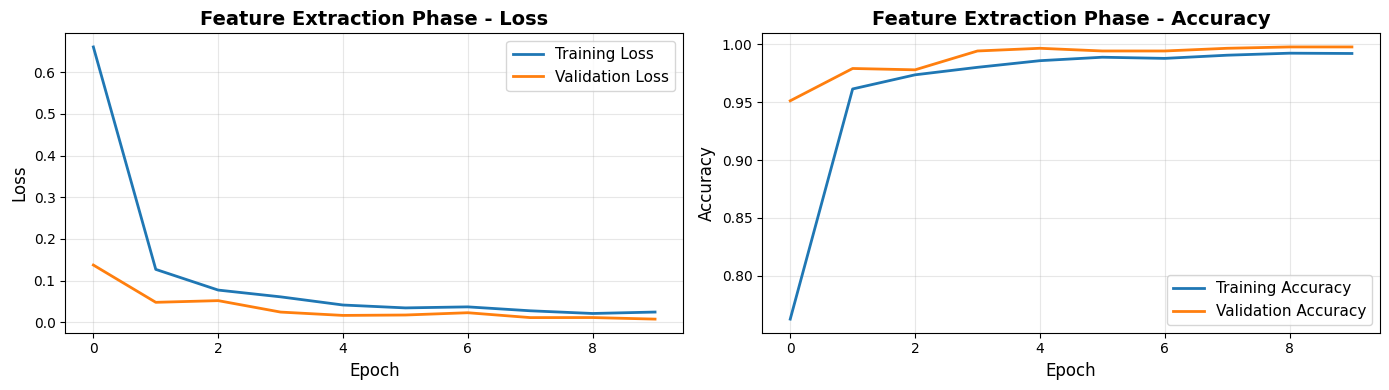

In [18]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot loss
axes[0].plot(train_losses, label='Training Loss', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Feature Extraction Phase - Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(train_accuracy, label='Training Accuracy', linewidth=2)
axes[1].plot(val_accuracy, label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Feature Extraction Phase - Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h3>Model Evaluation</h3>

In [19]:
# Evaluate on test set
print("="*70)
print("FEATURE EXTRACTION PHASE - EVALUATION")
print("="*70)

# Get predictions on test set
y_pred_probs = model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from test dataset
y_true = []
for _, labels in test_dataset:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

FEATURE EXTRACTION PHASE - EVALUATION
Predictions shape: (861,)
True labels shape: (861,)


In [20]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*70)
print("FEATURE EXTRACTION PHASE - RESULTS")
print("="*70)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("="*70)

# Store results
accuracy_extraction = accuracy
precision_extraction = precision
recall_extraction = recall
f1_extraction = f1


FEATURE EXTRACTION PHASE - RESULTS
Accuracy  : 0.9977
Precision : 0.9977
Recall    : 0.9977
F1 Score  : 0.9977



CLASSIFICATION REPORT - FEATURE EXTRACTION PHASE
              precision    recall  f1-score   support

      Cloudy     1.0000    1.0000    1.0000       199
  Green Area     1.0000    0.9914    0.9957       233
      Desert     1.0000    1.0000    1.0000       171
       Water     0.9918    1.0000    0.9959       242
    Vehicles     1.0000    1.0000    1.0000        16

    accuracy                         0.9977       861
   macro avg     0.9984    0.9983    0.9983       861
weighted avg     0.9977    0.9977    0.9977       861



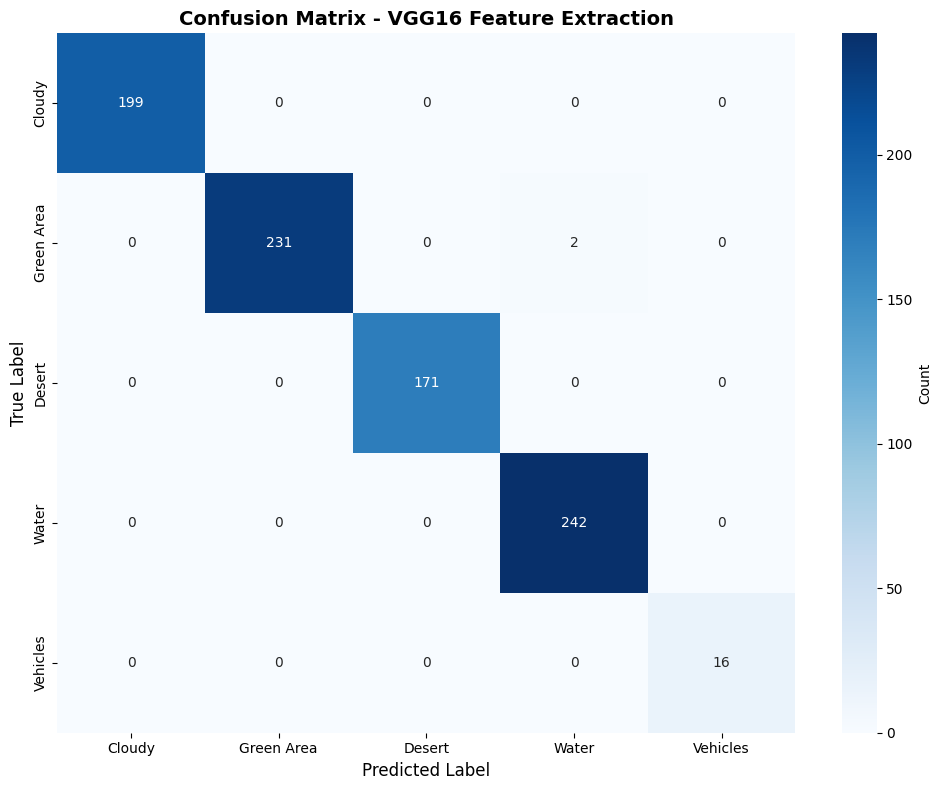

In [21]:
# Print classification report and confusion matrix
class_names = ["Cloudy", "Green Area", "Desert", "Water", "Vehicles"]
print("\nCLASSIFICATION REPORT - FEATURE EXTRACTION PHASE")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - VGG16 Feature Extraction', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

---

## Fine-Tuning Phase: Unfreezing and Re-training Deeper Layers

After feature extraction, we now **unfreeze the last 2 convolutional blocks** of VGG16 to adapt the deeper learned features to our satellite image domain. This allows the model to adjust its mid-level and high-level feature representations specifically for our classification task.

In [22]:
# Fine-tuning phase: unfreeze last convolutional blocks
print("\n" + "="*70)
print("FINE-TUNING PHASE - UNFREEZING LAYERS")
print("="*70)

# Unfreeze last 2 blocks of VGG16 (layers after index 15)
# VGG16 has 16 convolutional layers, we unfreeze the last ~4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Compile model with lower learning rate for fine-tuning
ft_learning_rate = 1e-5
ft_optimizer = keras.optimizers.Adam(learning_rate=ft_learning_rate)

model.compile(
    optimizer=ft_optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable Layers: {sum(1 for layer in base_model.layers if layer.trainable)}")
print(f"Total Base Layers: {len(base_model.layers)}")
print(f"Fine-tuning Learning Rate: {ft_learning_rate}")
print("="*70)


FINE-TUNING PHASE - UNFREEZING LAYERS
Trainable Layers: 4
Total Base Layers: 19
Fine-tuning Learning Rate: 1e-05


In [23]:
# Fine-tuning training setup
ft_epochs = 5

In [24]:
# Fine-tuning using Keras model.fit()
print("="*70)
print("FINE-TUNING PHASE - TRAINING")
print("="*70)

ft_start_time = time.time()

ft_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=ft_epochs,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=1,
            min_lr=1e-8,
            verbose=1
        )
    ]
)

ft_end_time = time.time()
ft_training_time = ft_end_time - ft_start_time
ft_training_time_minutes = ft_training_time / 60

print(f"\nFine-tuning Training time: {ft_training_time:.2f} seconds ({ft_training_time_minutes:.2f} minutes)")

# Extract histories
ft_train_losses = ft_history.history['loss']
ft_val_losses = ft_history.history['val_loss']
ft_train_accuracy = ft_history.history['accuracy']
ft_val_accuracy = ft_history.history['val_accuracy']

FINE-TUNING PHASE - TRAINING
Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.9930 - loss: 0.0204 - val_accuracy: 0.9977 - val_loss: 0.0106 - learning_rate: 1.0000e-05
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9948 - loss: 0.0127
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
126/126 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9950 - loss: 0.0153 - val_accuracy: 0.9919 - val_loss: 0.0239 - learning_rate: 1.0000e-05
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9980 - loss: 0.0053 - val_accuracy: 0.9988 - val_loss: 0.0076 - learning_rate: 5.0000e-06
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9988 - loss: 0.0037 - val_accuracy: 0.9988 - val_loss: 0.0055 - learning_rate: 5.0000e-06
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9998 - loss: 0.0025
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
126/126 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/

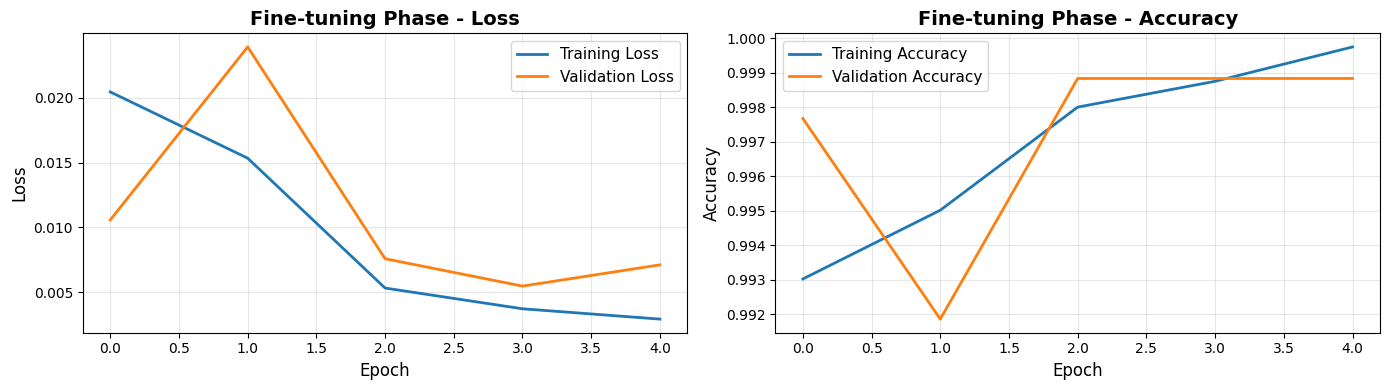

In [25]:
# Plot fine-tuning history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot loss
axes[0].plot(ft_train_losses, label='Training Loss', linewidth=2)
axes[0].plot(ft_val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Fine-tuning Phase - Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(ft_train_accuracy, label='Training Accuracy', linewidth=2)
axes[1].plot(ft_val_accuracy, label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Fine-tuning Phase - Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Evaluate fine-tuned model on test set
print("="*70)
print("FINE-TUNING PHASE - EVALUATION")
print("="*70)

# Get predictions on test set
y_pred_probs_ft = model.predict(test_dataset, verbose=0)
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)

# Get true labels (same as before)
print(f"Predictions shape: {y_pred_ft.shape}")
print(f"True labels shape: {y_true.shape}")

# Calculate metrics
accuracy_ft = accuracy_score(y_true, y_pred_ft)
precision_ft = precision_score(y_true, y_pred_ft, average='weighted', zero_division=0)
recall_ft = recall_score(y_true, y_pred_ft, average='weighted', zero_division=0)
f1_ft = f1_score(y_true, y_pred_ft, average='weighted', zero_division=0)

print("\n" + "="*70)
print("FINE-TUNING PHASE - RESULTS")
print("="*70)
print(f"Accuracy  : {accuracy_ft:.4f}")
print(f"Precision : {precision_ft:.4f}")
print(f"Recall    : {recall_ft:.4f}")
print(f"F1 Score  : {f1_ft:.4f}")
print("="*70)

FINE-TUNING PHASE - EVALUATION
Predictions shape: (861,)
True labels shape: (861,)

FINE-TUNING PHASE - RESULTS
Accuracy  : 0.9988
Precision : 0.9988
Recall    : 0.9988
F1 Score  : 0.9988


In [27]:
# Print classification report for fine-tuned model
class_names = ["Cloudy", "Green Area", "Desert", "Water", "Vehicles"]
print("\nCLASSIFICATION REPORT - FINE-TUNING PHASE")
print("="*70)
print(classification_report(y_true, y_pred_ft, target_names=class_names, digits=4))

# Print comparison
print("\n" + "="*70)
print(f"{'Metric':<20} {'Feature Extraction':>20} {'Fine-Tuned':>15}")
print("="*70)
print(f"{'Accuracy':<20} {accuracy_extraction:>20.4f} {accuracy_ft:>15.4f}")
print(f"{'Precision':<20} {precision_extraction:>20.4f} {precision_ft:>15.4f}")
print(f"{'Recall':<20} {recall_extraction:>20.4f} {recall_ft:>15.4f}")
print(f"{'F1 Score':<20} {f1_extraction:>20.4f} {f1_ft:>15.4f}")
print("="*70)


CLASSIFICATION REPORT - FINE-TUNING PHASE
              precision    recall  f1-score   support

      Cloudy     1.0000    1.0000    1.0000       199
  Green Area     0.9957    1.0000    0.9979       233
      Desert     1.0000    1.0000    1.0000       171
       Water     1.0000    0.9959    0.9979       242
    Vehicles     1.0000    1.0000    1.0000        16

    accuracy                         0.9988       861
   macro avg     0.9991    0.9992    0.9992       861
weighted avg     0.9988    0.9988    0.9988       861


Metric                 Feature Extraction      Fine-Tuned
Accuracy                           0.9977          0.9988
Precision                          0.9977          0.9988
Recall                             0.9977          0.9988
F1 Score                           0.9977          0.9988


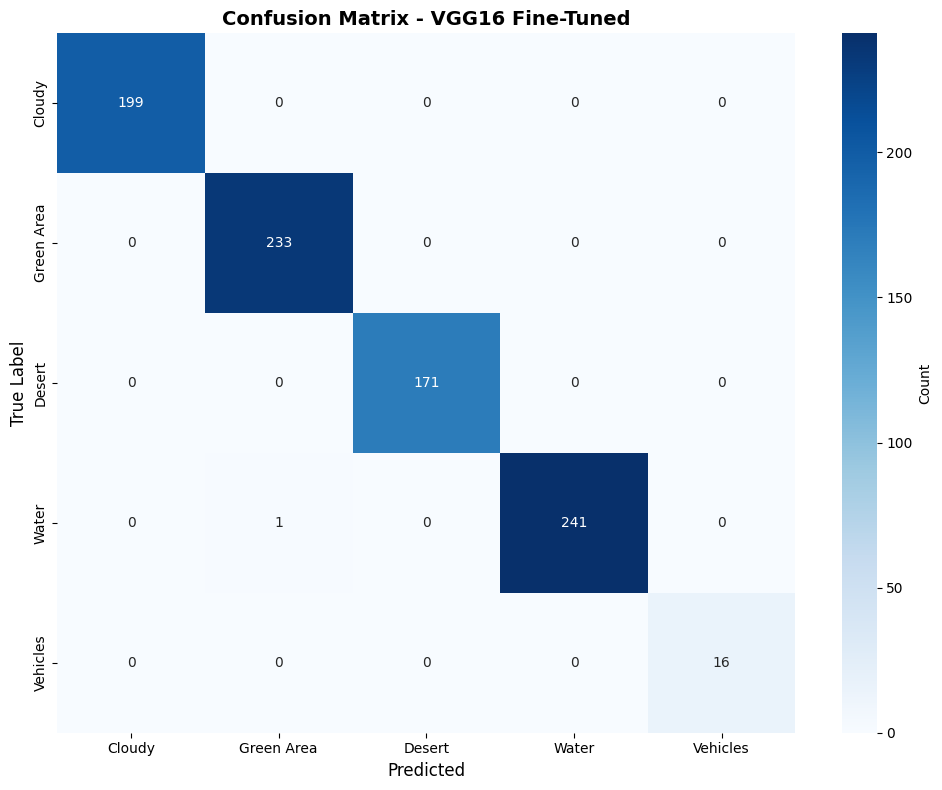

In [28]:
# Plot confusion matrix for fine-tuned model
cm_ft = confusion_matrix(y_true, y_pred_ft)
class_names = ["Cloudy", "Green Area", "Desert", "Water", "Vehicles"]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - VGG16 Fine-Tuned", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
def predict_image(img_path):
    """
    Load an image and predict its class using the fine-tuned VGG16 model
    
    Args:
        img_path: Path to the image file
    
    Returns:
        Predicted class index and probabilities
    """
    # Load and preprocess image
    image = tf.io.read_file(img_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, IMG_SIZE)
    
    # Normalize using ImageNet statistics
    image = (image - MEAN) / STD
    
    # Add batch dimension
    image = tf.expand_dims(image, axis=0)
    
    # Make prediction
    predictions = model.predict(image, verbose=0)
    pred_class = np.argmax(predictions[0])
    
    return pred_class, predictions[0]


Image: image.png
Predicted Class: Desert
Confidence: 78.03%

Class Probabilities:
  Cloudy         : 0.2197
  Green Area     : 0.0000
  Desert         : 0.7803
  Water          : 0.0000
  Vehicles       : 0.0000


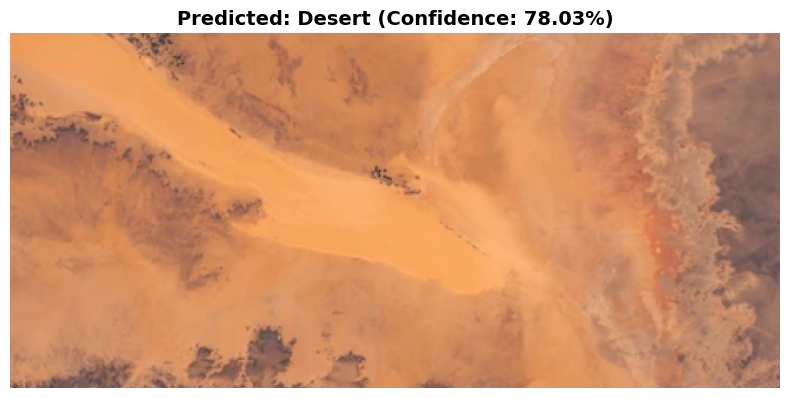

In [31]:
# Example prediction on a test image
try:
    img_path = "image.png"
    
    if os.path.exists(img_path):
        pred_class, probabilities = predict_image(img_path)
        
        class_names = ["Cloudy", "Green Area", "Desert", "Water", "Vehicles"]
        
        print(f"\nImage: {img_path}")
        print(f"Predicted Class: {class_names[pred_class]}")
        print(f"Confidence: {probabilities[pred_class]:.2%}")
        print("\nClass Probabilities:")
        for i, (name, prob) in enumerate(zip(class_names, probabilities)):
            print(f"  {name:15s}: {prob:.4f}")
        
        # Visualize prediction
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f"Predicted: {class_names[pred_class]} (Confidence: {probabilities[pred_class]:.2%})", 
                 fontsize=14, fontweight='bold')
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Image file '{img_path}' not found. Please provide a valid image path.")
except Exception as e:
    print(f"Error during prediction: {str(e)}")